# Benchmarking ESM2 Against External Pathogenic Variant Predictors

This notebook compares the performance of the ESM2-based models (LogReg, Random Forest) against existing pathogenic variant prediction tools on gene-specific MAVE (Multiplexed Assays of Variant Effect) datasets:
- **BRCA1** (n=1908 variants)
- **MSH2** (n variants)
- **PTEN** (n variants)
- **TP53** (n variants)

## External Predictors Available
- CADD (raw rank score)
- MPC (Missense Badness, PolyPhen-2, Constraint)
- PrimateAI
- M-CAP
- REVEL
- gMVP
- MVP
- ClinPred
- BayesDel
- EVmutation

## Workflow
1. Load external predictor scores from MAVE4genes_corrected.xlsx
2. Load ESM2 model predictions from local/HPC data
3. Compute precision-recall curves for all models
4. Generate comparative visualization across genes

## 1. Import Required Libraries (CSV-based workflow)

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Load Gene Source Data and Model Predictions

Load external predictor scores from MAVE4genes_corrected.xlsx (local copy of Dylan's data) and prepare gene-specific datasets.

In [35]:
# Define data paths
from pathlib import Path
import os

# Get notebook directory
notebook_dir = Path(os.getcwd())
print(f"Current working directory: {notebook_dir}\n")

# Local data directory (default: local repo copy)
# Optional override: export LOCAL_DATA_DIR="/path/to/local/data"
LOCAL_DATA_DIR = Path(os.getenv("LOCAL_DATA_DIR", "../data/Dylan Tan"))

# HPC base directory (single source of truth)
# Optional override: export HPC_BASE="/blue/xiaofan/dtan1"
HPC_BASE = Path(os.getenv("HPC_BASE", "/blue/xiaofan/dtan1"))
HPC_DATA_DIR = HPC_BASE / "Datasets"
HPC_PREDICTIONS_DIR = HPC_BASE / "Output_Folder/ESM2_PrimateAI_Scripts/Baseline/MLP_Simple/13"

print(f"LOCAL_DATA_DIR: {LOCAL_DATA_DIR}")
print(f"HPC_BASE: {HPC_BASE}")
print(f"HPC_DATA_DIR: {HPC_DATA_DIR}")
print(f"HPC_PREDICTIONS_DIR: {HPC_PREDICTIONS_DIR}\n")

# Gene names
GENES = ["BRCA1", "MSH2", "PTEN", "TP53"]

# Try local first, then HPC
MAVE_GENES_FILE = LOCAL_DATA_DIR / "MAVE4genes_corrected.xlsx"
if not MAVE_GENES_FILE.exists():
    MAVE_GENES_FILE = HPC_DATA_DIR / "MAVE4genes_corrected.xlsx"
    print(f"Using HPC path for MAVE4genes: {MAVE_GENES_FILE}")
else:
    print(f"Using local path for MAVE4genes: {MAVE_GENES_FILE}\n")

# Load external predictor scores from Excel (Dylan's MAVE data)
print("Loading external predictor scores from MAVE4genes_corrected.xlsx...\n")
gene_source_dict = {}
for gene in GENES:
    try:
        df = pd.read_excel(MAVE_GENES_FILE, sheet_name=gene, header=0)
        gene_source_dict[gene] = df
        print(f"{gene}: shape={df.shape}")
        print(f"  Columns: {list(df.columns[:20])}")
        print(f"  Predictor scores (columns 8-18): {list(df.iloc[:, 8:18].columns)}\n")
    except Exception as e:
        print(f"Error loading {gene}: {e}\n")

if len(gene_source_dict) > 0:
    print(f"✓ Successfully loaded {len(gene_source_dict)} genes from MAVE4genes")
    print(f"\nExample: BRCA1 first row of predictor scores:")
    print(gene_source_dict["BRCA1"].iloc[0, 8:18])
else:
    print("\n⚠ Warning: No genes loaded. Check MAVE_GENES_FILE path.")

Current working directory: /Users/angelhdmorenu/Desktop/EGN 6933 – Project in Applied Data Science/Machine Learning Classification of Pathogenic vs. Benign Missense Variants Using Protein Language Model Embeddings/notebooks

LOCAL_DATA_DIR: ../data/Dylan Tan
HPC_BASE: /blue/xiaofan/dtan1
HPC_DATA_DIR: /blue/xiaofan/dtan1/Datasets
HPC_PREDICTIONS_DIR: /blue/xiaofan/dtan1/Output_Folder/ESM2_PrimateAI_Scripts/Baseline/MLP_Simple/13

Using local path for MAVE4genes: ../data/Dylan Tan/MAVE4genes_corrected.xlsx

Loading external predictor scores from MAVE4genes_corrected.xlsx...

BRCA1: shape=(1908, 24)
  Columns: ['chrom', 'pos', 'ref', 'alt', 'ref_aa', 'alt_aa', 'genename', 'transcript_id', 'CADD_raw_rankscore', 'MPC_rankscore', 'PrimateAI_rankscore', 'M-CAP_rankscore', 'REVEL_rankscore', 'gMVP_rankscore', 'MVP_rankscore', 'ClinPred', 'BayesDel', 'EVmutation', 'Pathogenicity', 'Protein']
  Predictor scores (columns 8-18): ['CADD_raw_rankscore', 'MPC_rankscore', 'PrimateAI_rankscore', 'M-CA

## 3. Workflow Note

This notebook currently uses a **CSV-based prediction workflow**:
- ESM2 model outputs from `*_Predictions.csv`
- External predictors from `MAVE4genes_corrected.xlsx`

Pickle-based embedding utilities were removed from this notebook to keep it focused on benchmark evaluation and plotting.

In [36]:
# No additional utility functions are required for the current CSV-based workflow.
# This cell is intentionally minimal to keep notebook structure consistent.
print("Using CSV-based benchmark pipeline (no pickle embedding preprocessing in this notebook).")

Using CSV-based benchmark pipeline (no pickle embedding preprocessing in this notebook).


## 4. Prepare and Combine Prediction Datasets

Load ESM2 prediction files and combine with external predictor scores from MAVE4genes.

**Path configuration (env-var friendly):**
- Local default data dir: `../data/Dylan Tan` (override with `LOCAL_DATA_DIR`)
- HPC base dir: `HPC_BASE=/blue/xiaofan/dtan1`
- Derived HPC paths:
  - `HPC_DATA_DIR = HPC_BASE / "Datasets"`
  - `HPC_PREDICTIONS_DIR = HPC_BASE / "Output_Folder/ESM2_PrimateAI_Scripts/Baseline/MLP_Simple/13"`

In [37]:
# Load ESM2 predictions from CSV files
# These are generated from the MLP_Simple model trained on ESM2 embeddings

print("=" * 70)
print("PREPARING PREDICTION DATASETS")
print("=" * 70)

predictions_datasets = {}
predictions_csv_loaded = {}

# Local search roots (support both old and new layouts)
local_prediction_roots = [
    LOCAL_DATA_DIR,
    LOCAL_DATA_DIR / "predictions",
]

for gene in GENES:
    # Try local candidate paths first
    local_candidates = [root / f"{gene}_Predictions.csv" for root in local_prediction_roots]
    hpc_csv = HPC_PREDICTIONS_DIR / f"{gene}_Predictions.csv"

    prediction_file = None
    source = None

    for candidate in local_candidates:
        if candidate.exists():
            prediction_file = candidate
            source = "local"
            break

    if prediction_file is None and hpc_csv.exists():
        prediction_file = hpc_csv
        source = "HPC"

    if prediction_file is None:
        print(f"\n⚠ {gene}: Prediction CSV not found.")
        print("   Tried local:")
        for c in local_candidates:
            print(f"     - {c}")
        print(f"   Tried HPC:\n     - {hpc_csv}")
        continue

    try:
        # Load ESM2 predictions CSV
        df_predictions = pd.read_csv(prediction_file, header=0)
        predictions_csv_loaded[gene] = df_predictions
        print(f"\n{gene} ({source}):")
        print(f"  File: {prediction_file}")
        print(f"  Shape: {df_predictions.shape}")
        print(f"  Columns: {list(df_predictions.columns)}")

        # Get source data for external predictor scores
        df_source = gene_source_dict[gene]

        # Combine ESM2 predictions with external predictor scores
        # df_predictions should have: True Label, Predicted Label, Predicted Probability
        # df_source has external predictors in columns 8-18
        predictor_cols = df_source.iloc[:, 8:18]
        df_combined = pd.concat(
            [df_predictions.reset_index(drop=True), predictor_cols.reset_index(drop=True)],
            axis=1,
        )

        predictions_datasets[gene] = df_combined
        print(f"  Combined shape: {df_combined.shape}")

    except Exception as e:
        print(f"\n✗ Error processing {gene}: {e}")

if len(predictions_datasets) > 0:
    print(f"\n✓ Successfully loaded {len(predictions_datasets)}/{len(GENES)} genes with predictions")
else:
    print(f"\n✗ No prediction datasets loaded!")

PREPARING PREDICTION DATASETS

BRCA1 (local):
  File: ../data/Dylan Tan/predictions/BRCA1_Predictions.csv
  Shape: (1908, 3)
  Columns: ['True Label', 'Predicted Label', 'Predicted Probability']
  Combined shape: (1908, 13)

MSH2 (local):
  File: ../data/Dylan Tan/predictions/MSH2_Predictions.csv
  Shape: (5853, 3)
  Columns: ['True Label', 'Predicted Label', 'Predicted Probability']
  Combined shape: (5853, 13)

PTEN (local):
  File: ../data/Dylan Tan/predictions/PTEN_Predictions.csv
  Shape: (1894, 3)
  Columns: ['True Label', 'Predicted Label', 'Predicted Probability']
  Combined shape: (1894, 13)

TP53 (local):
  File: ../data/Dylan Tan/predictions/TP53_Predictions.csv
  Shape: (1129, 3)
  Columns: ['True Label', 'Predicted Label', 'Predicted Probability']
  Combined shape: (1129, 13)

✓ Successfully loaded 4/4 genes with predictions


## 5. Generate Precision-Recall Curves

For each gene, compute PR curves and AUC scores for all predictor models including Capstone-ESM2 and external predictors.

In [38]:
# Model names corresponding to columns 3-13 in predictions_datasets
# Column 0: True Label
# Column 1: Predicted Label
# Column 2: Predicted Probability (ESM2)
# Columns 3-13: External predictors
model_names = ["Ours (ESM2)", "CADD", "MPC", "PrimateAI", "M-CAP", "REVEL",
"gMVP", "MVP", "ClinPred", "BayesDel", "EVmutation"]

# Compute metrics for each gene and model
print("=" * 70)
print("COMPUTING PRECISION-RECALL METRICS")
print("=" * 70)

metrics_by_gene = {}

for gene_name, df in predictions_datasets.items():
    print(f"\n{gene_name}:")
    df_clean = df.dropna()
    print(f"  Non-null records: {len(df_clean)}/{len(df)}")
    
    y_true = df_clean['True Label'].values
    metrics = {}
    
    # ESM2 model (column 2: Predicted Probability)
    y_scores_esm2 = df_clean['Predicted Probability'].values
    print(f"  ESM2 scores - min: {np.min(y_scores_esm2):.4f}, max: {np.max(y_scores_esm2):.4f}, mean: {np.mean(y_scores_esm2):.4f}")
    
    if len(np.unique(y_true)) > 1:  # Only compute if both classes present
        try:
            precision, recall, _ = precision_recall_curve(y_true, y_scores_esm2)
            prc_auc = auc(recall, precision)
            auroc = roc_auc_score(y_true, y_scores_esm2)
            metrics['Ours (ESM2)'] = {'PR_AUC': prc_auc, 'ROC_AUC': auroc}
            print(f"    ✓ Ours (ESM2): PR-AUC={prc_auc:.4f}, ROC-AUC={auroc:.4f}")
        except Exception as e:
            print(f"    ✗ Error computing ESM2 metrics: {e}")
    else:
        print(f"    ✗ ESM2: Skipped (only 1 class in labels)")
    
    # External predictors (columns 3 onwards)
    for i, model_name in enumerate(model_names[1:], 3):
        y_scores = df_clean.iloc[:, i].values
        # Convert to numeric, handling NaN
        y_scores = pd.to_numeric(y_scores, errors='coerce')
        y_scores_valid = y_scores[~np.isnan(y_scores)]
        y_true_valid = y_true[~np.isnan(y_scores)]
        
        if len(y_scores_valid) > 0:
            print(f"    {model_name}: {len(y_scores_valid)}/{len(y_scores)} valid values, ", end="")
            if len(np.unique(y_true_valid)) > 1:
                try:
                    precision, recall, _ = precision_recall_curve(y_true_valid, y_scores_valid)
                    prc_auc = auc(recall, precision)
                    auroc = roc_auc_score(y_true_valid, y_scores_valid)
                    metrics[model_name] = {'PR_AUC': prc_auc, 'ROC_AUC': auroc}
                    print(f"✓ PR-AUC={prc_auc:.4f}, ROC-AUC={auroc:.4f}")
                except Exception as e:
                    print(f"✗ Error: {e}")
            else:
                print(f"✗ Skipped (only 1 class)")
        else:
            print(f"    {model_name}: ✗ No valid values")
    
    metrics_by_gene[gene_name] = metrics
    print(f"  Metrics computed: {len(metrics)} models")

print("\n✓ All genes processed")

COMPUTING PRECISION-RECALL METRICS

BRCA1:
  Non-null records: 1844/1908
  ESM2 scores - min: 0.0001, max: 0.9981, mean: 0.1497
    ✓ Ours (ESM2): PR-AUC=0.7501, ROC-AUC=0.8900
    CADD: 1844/1844 valid values, ✓ PR-AUC=0.4948, ROC-AUC=0.7948
    MPC: 1844/1844 valid values, ✓ PR-AUC=0.4201, ROC-AUC=0.7013
    PrimateAI: 1844/1844 valid values, ✓ PR-AUC=0.4461, ROC-AUC=0.7442
    M-CAP: 1844/1844 valid values, ✓ PR-AUC=0.6927, ROC-AUC=0.8663
    REVEL: 1844/1844 valid values, ✓ PR-AUC=0.7371, ROC-AUC=0.8813
    gMVP: 1844/1844 valid values, ✓ PR-AUC=0.8171, ROC-AUC=0.9066
    MVP: 1844/1844 valid values, ✓ PR-AUC=0.6060, ROC-AUC=0.8250
    ClinPred: 1844/1844 valid values, ✓ PR-AUC=0.6494, ROC-AUC=0.8555
    BayesDel: 1844/1844 valid values, ✓ PR-AUC=0.7550, ROC-AUC=0.8973
    EVmutation: 1844/1844 valid values, ✓ PR-AUC=0.4294, ROC-AUC=0.8061
  Metrics computed: 11 models

MSH2:
  Non-null records: 5846/5853
  ESM2 scores - min: 0.0003, max: 0.9974, mean: 0.2323
    ✓ Ours (ESM2): PR-

## 6. Visualize and Compare Model Performance

Create comparative precision-recall curves for all four genes, showing performance of Capstone-ESM2 versus external predictors.


Current working directory: /Users/angelhdmorenu/Desktop/EGN 6933 – Project in Applied Data Science/Machine Learning Classification of Pathogenic vs. Benign Missense Variants Using Protein Language Model Embeddings/notebooks
✓ Saved figure: /Users/angelhdmorenu/Desktop/EGN 6933 – Project in Applied Data Science/Machine Learning Classification of Pathogenic vs. Benign Missense Variants Using Protein Language Model Embeddings/results/benchmark_pr_curves_by_gene.png
  File size: 1,945,155 bytes
✓ Saved figure: /Users/angelhdmorenu/Desktop/EGN 6933 – Project in Applied Data Science/Machine Learning Classification of Pathogenic vs. Benign Missense Variants Using Protein Language Model Embeddings/results/benchmark_pr_curves_by_gene.png
  File size: 1,945,155 bytes


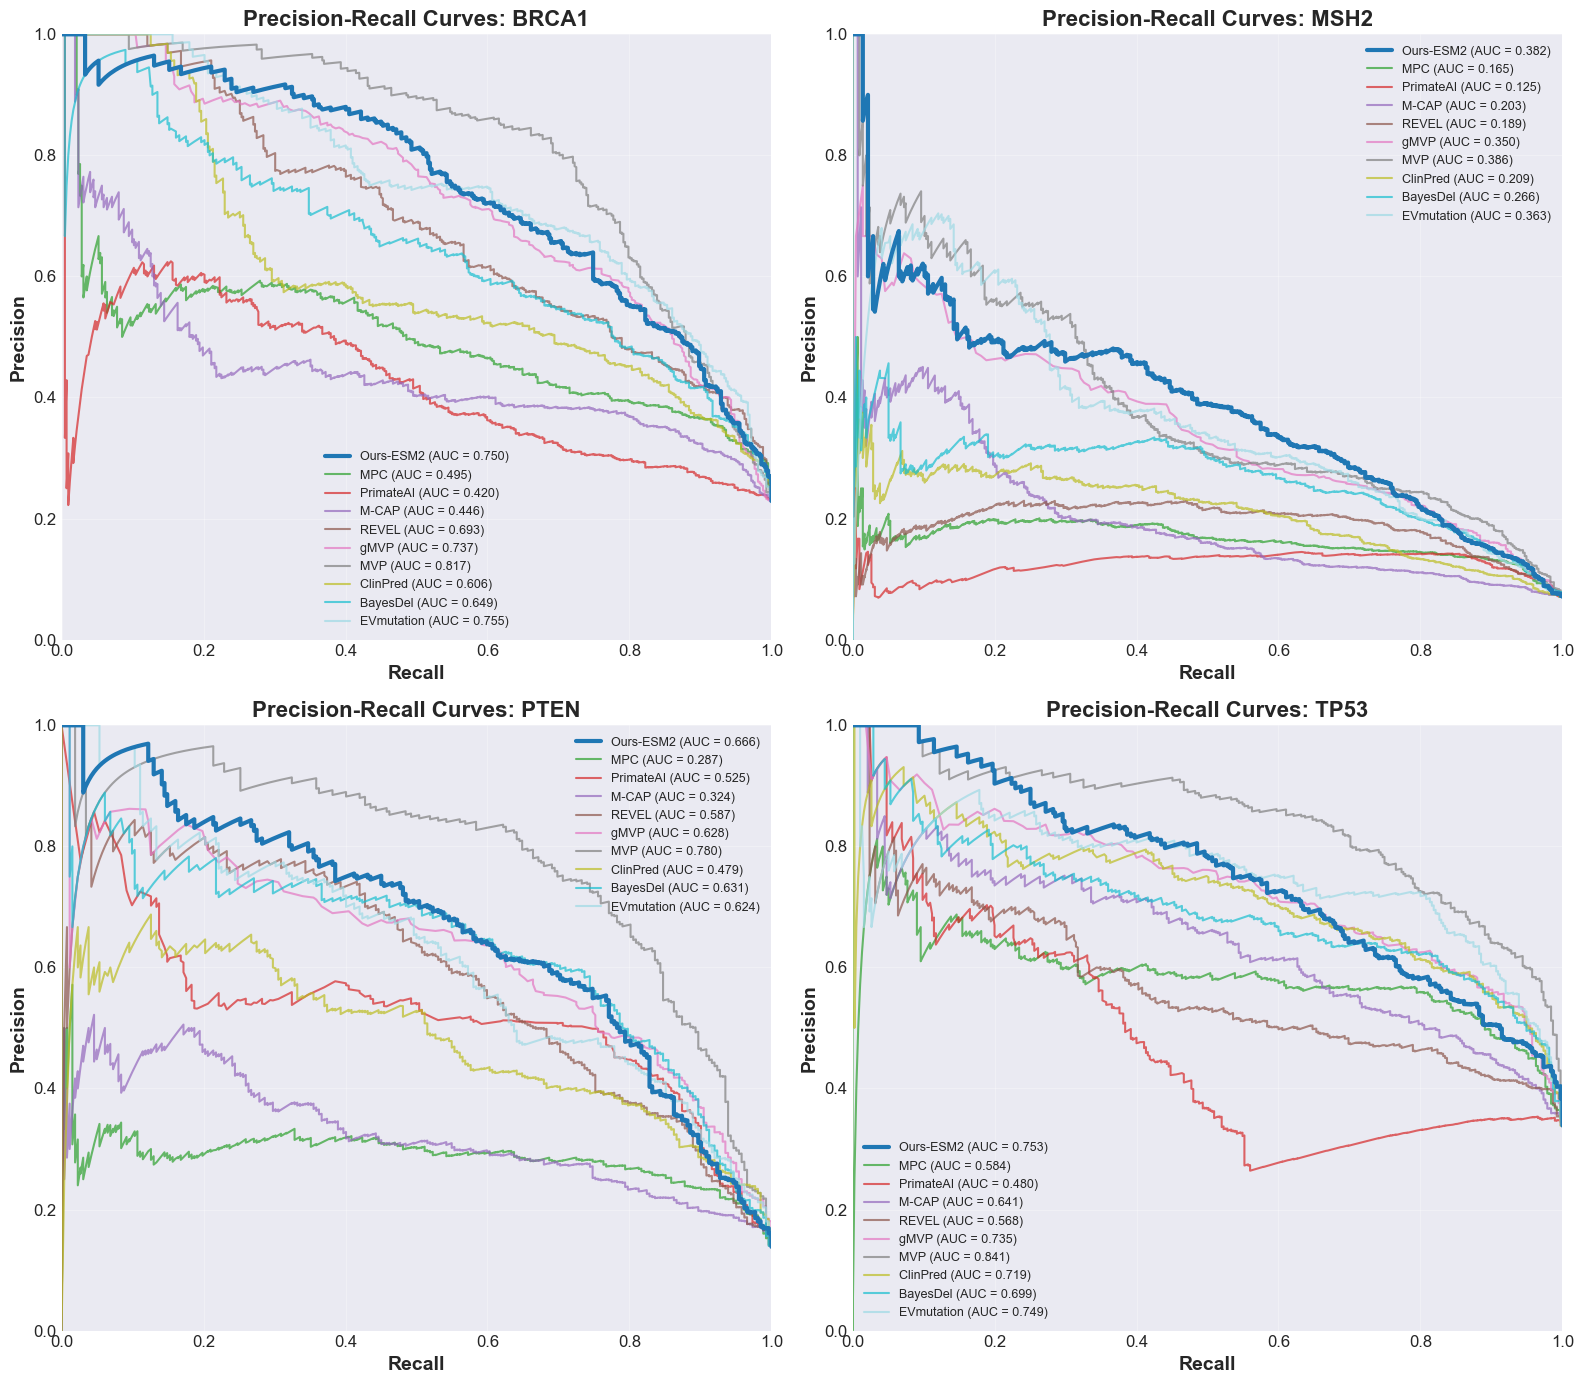

In [39]:
# Create 2x2 subplot figure for PR curves
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Color palette for models (Capstone-ESM2 in bold color)
colors = plt.cm.tab20(np.linspace(0, 1, len(model_names)))

for idx, gene_name in enumerate(GENES):
    if gene_name not in predictions_datasets:
        print(f"Skipping {gene_name} - no predictions loaded")
        continue

    df = predictions_datasets[gene_name].dropna()
    if len(df) == 0:
        print(f"Skipping {gene_name} - all rows are NaN")
        continue

    # Get true labels from first column
    true_label_col = df.columns[0]
    y_true = df[true_label_col].astype(int).values

    ax = axes[idx]
    plt.rcParams.update({'font.size': 12})

    # Plot PR curve for Ours-ESM2
    esm2_col = df.columns[2] if len(df.columns) > 2 else None
    if esm2_col:
        y_scores_esm2 = pd.to_numeric(df[esm2_col], errors='coerce').values
        valid_idx = ~np.isnan(y_scores_esm2)
        y_scores_valid = y_scores_esm2[valid_idx]
        y_true_valid = y_true[valid_idx]

        if len(y_scores_valid) > 0 and len(np.unique(y_true_valid)) > 1:
            try:
                precision, recall, _ = precision_recall_curve(y_true_valid, y_scores_valid)
                prc_auc = auc(recall, precision)
                ax.plot(recall, precision, label=f"Ours-ESM2 (AUC = {prc_auc:.3f})",
                        color=colors[0], linewidth=3, alpha=1.0, zorder=10)
            except Exception as e:
                print(f"Error plotting Ours-ESM2 for {gene_name}: {e}")

    # Plot PR curves for external predictors
    for col_idx, col_name in enumerate(df.columns[3:], start=3):
        model_name = model_names[col_idx - 1] if col_idx - 1 < len(model_names) else col_name

        y_scores = pd.to_numeric(df[col_name], errors='coerce').values
        valid_idx = ~np.isnan(y_scores)
        y_scores_valid = y_scores[valid_idx]
        y_true_valid = y_true[valid_idx]

        if len(y_scores_valid) > 0 and len(np.unique(y_true_valid)) > 1:
            try:
                precision, recall, _ = precision_recall_curve(y_true_valid, y_scores_valid)
                prc_auc = auc(recall, precision)
                ax.plot(recall, precision, label=f"{model_name} (AUC = {prc_auc:.3f})",
                        color=colors[col_idx - 1], linewidth=1.5, alpha=0.7)
            except Exception:
                pass  # Skip if error

    # Formatting
    ax.set_xlabel("Recall", fontsize=14, fontweight='bold')
    ax.set_ylabel("Precision", fontsize=14, fontweight='bold')
    ax.set_title(f"Precision-Recall Curves: {gene_name}", fontsize=16, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.tight_layout()

# Determine save path - use absolute path
print(f"\nCurrent working directory: {Path.cwd()}")
PROJECT_ROOT = Path("/Users/angelhdmorenu/Desktop/EGN 6933 – Project in Applied Data Science/Machine Learning Classification of Pathogenic vs. Benign Missense Variants Using Protein Language Model Embeddings")
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

save_path = results_dir / "benchmark_pr_curves_by_gene.png"

try:
    plt.savefig(str(save_path), dpi=300, bbox_inches='tight')
    print(f"✓ Saved figure: {save_path}")
    # Verify file exists
    if save_path.exists():
        file_size = save_path.stat().st_size
        print(f"  File size: {file_size:,} bytes")
    else:
        print(f"  Warning: File not found after save")
except Exception as e:
    print(f"✗ Error saving figure: {e}")

plt.show()

## Summary

This notebook benchmarks the **Capstone-ESM2** model (defined as the full **Capstone Variant Pathogenicity Model (ESM2)**) against established external tools (CADD, PrimateAI, REVEL, etc.) on gene-specific MAVE datasets.

### Key Data Sources
- **External Predictor Scores:** `data/Dylan Tan/MAVE4genes_corrected.xlsx` (local copy)
- **ESM2 Predictions:** Local `data/Dylan Tan/predictions/*.csv` or HPC path via `HPC_BASE`
- **Gene-specific Test Sets:** BRCA1, MSH2, PTEN, TP53 (n≈2000 variants each)

### External Predictors Included
- **CADD** (CADD_raw_rankscore)
- **MPC** (Missense Badness, PolyPhen-2, Constraint)
- **PrimateAI** (species-specific conservation)
- **M-CAP** (Combined Annotation-Dependent Depletion)
- **REVEL** (Rare Exome Variant Ensemble Learner)
- **gMVP** (genomic Model for Variant Pathogenicity)
- **MVP** (Meta-analysis of Variant Effects)
- **ClinPred** (Clinical impact prediction)
- **BayesDel** (Bayesian deletion index)
- **EVmutation** (Evolutionary mutation analysis)